# Análisis Exploratorio de Datos (EDA)
## Detección de Fraude Contable mediante Aprendizaje Automático
### TFG — Ingeniería Matemática, CEU San Pablo

**Dataset:** Bao et al. (2020), *Journal of Accounting Research* 58(1):199-235
**Fuente:** `data/data_FraudDetection_JAR2020.csv`
**Periodo cubierto:** 1990-2014
**Objetivo:** Identificar patrones en los datos antes de proceder al modelado, prestando especial atención al desequilibrio de clases, la estructura temporal y el fenómeno del fraude serial.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')

# Estilo visual homogéneo para toda la memoria
sns.set_theme(style="whitegrid")
sns.set_palette("muted")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Crear directorio de figuras si no existe
os.makedirs('../figures/eda', exist_ok=True)

# ── Cargar el dataset ──────────────────────────────────────────────────────
df = pd.read_csv('../data/data_FraudDetection_JAR2020.csv')
print(f"Dataset cargado correctamente.")
print(f"Dimensiones: {df.shape[0]:,} observaciones × {df.shape[1]} variables")


Dataset cargado correctamente.
Dimensiones: 146,045 observaciones × 46 variables


---
## Pregunta 1: Shape, dtypes y descripción general del dataset

El primer paso en cualquier análisis exploratorio consiste en comprender la estructura del dataset: número de observaciones, tipos de datos de cada variable y cómo se organizan las columnas en grupos semánticamente coherentes. En este caso, las 46 columnas se agrupan en tres bloques funcionales claramente diferenciados según Bao et al. (2020).


In [2]:
# ── (a) Shape y tipos ─────────────────────────────────────────────────────
print(f"Shape: {df.shape}")
print(f"Observaciones: {df.shape[0]:,}  |  Variables: {df.shape[1]}")
print()
df.info()

# ── Definición de los tres grupos de columnas ────────────────────────────
cols_aux = ['fyear', 'gvkey', 'p_aaer', 'misstate']

cols_raw = [
    'act',   'ap',    'at',    'ceq',   'che',   'cogs',  'csho',
    'dlc',   'dltis', 'dltt',  'dp',    'ib',    'invt',  'ivao',
    'ivst',  'lct',   'lt',    'ni',    'ppegt', 'pstk',  're',
    'rect',  'sale',  'sstk',  'txp',   'txt',   'xint',  'prcc_f'
]

cols_derived = [
    'dch_wc', 'ch_rsst', 'dch_rec', 'dch_inv', 'soft_assets',
    'ch_cs',  'ch_cm',   'ch_roa',  'issue',   'bm',
    'dpi',    'reoa',    'EBIT',    'ch_fcf'
]

# Verificación
total = len(cols_aux) + len(cols_raw) + len(cols_derived)
assert total == df.shape[1], f"Recuento incorrecto: {total} != {df.shape[1]}"

print("\n" + "="*65)
print("AGRUPACIÓN DE LAS 46 COLUMNAS:")
print("="*65)
print(f"\n(a) Variables AUXILIARES ({len(cols_aux)}):")
print(f"    {cols_aux}")
print(f"\n(b) Variables CRUDAS Compustat ({len(cols_raw)}):")
for i in range(0, len(cols_raw), 7):
    print(f"    {cols_raw[i:i+7]}")
print(f"\n(c) Variables DERIVADAS ({len(cols_derived)}):")
for i in range(0, len(cols_derived), 7):
    print(f"    {cols_derived[i:i+7]}")
print(f"\nTotal verificado: {total} columnas ✓")


Shape: (146045, 46)
Observaciones: 146,045  |  Variables: 46

<class 'pandas.DataFrame'>
RangeIndex: 146045 entries, 0 to 146044
Data columns (total 46 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   fyear        146045 non-null  int64  
 1   gvkey        146045 non-null  int64  
 2   p_aaer       964 non-null     float64
 3   misstate     146045 non-null  int64  
 4   act          146045 non-null  float64
 5   ap           146045 non-null  float64
 6   at           146045 non-null  float64
 7   ceq          146045 non-null  float64
 8   che          146045 non-null  float64
 9   cogs         146045 non-null  float64
 10  csho         146045 non-null  float64
 11  dlc          146045 non-null  float64
 12  dltis        146045 non-null  float64
 13  dltt         146045 non-null  float64
 14  dp           146045 non-null  float64
 15  ib           146045 non-null  float64
 16  invt         146045 non-null  float64
 17  ivao         146

**Interpretación:**
Las variables auxiliares (`fyear`, `gvkey`, `p_aaer`, `misstate`) no son predictores: identifican unívocamente cada observación y proporcionan la etiqueta de fraude. Las 28 variables crudas son partidas contables extraídas directamente de Compustat (activos, pasivos, ingresos, etc.), denominadas en millones de dólares. Las 14 variables derivadas son ratios e indicadores calculados por Bao et al. para capturar cambios en la estructura financiera de un año a otro; estas serán excluidas del análisis exploratorio inicial para centrarse en los datos contables brutos.


---
## Distribución de la variable objetivo

La variable `misstate` es binaria: toma el valor 1 cuando la SEC ha publicado una Accounting and Auditing Enforcement Release (AAER) confirmando la existencia de fraude contable para esa empresa-año, y 0 en caso contrario. La prevalencia de la clase positiva determina en gran medida la estrategia de modelado (métricas de evaluación, técnicas de resampling, umbrales de decisión).


DISTRIBUCIÓN DE LA VARIABLE OBJETIVO (misstate)
No fraude (0) :  145,081  (99.340%)
Fraude    (1) :      964  (0.6601%)
Total         :  146,045
Ratio desbal. : 1 : 150  (legítimas por cada fraude)

AAER únicos   : 412


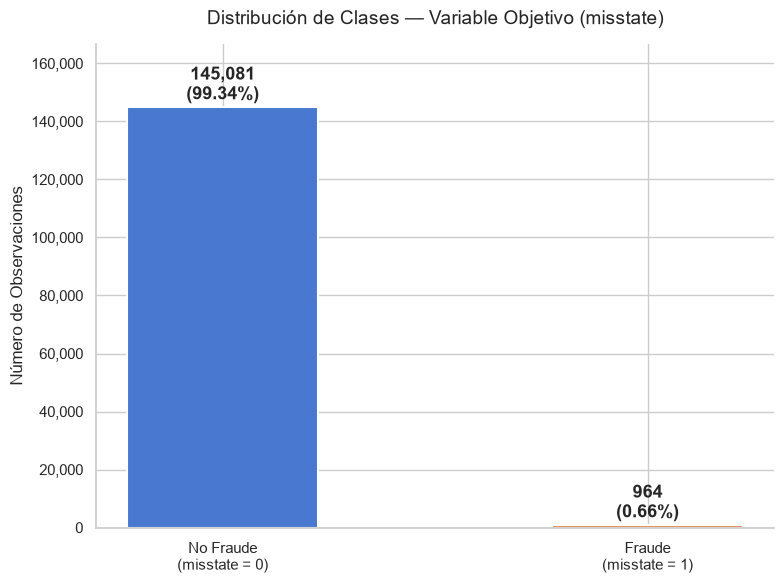

Figura guardada: figures/eda/fig01_class_distribution.png


In [3]:
# ── Recuento y prevalencia ────────────────────────────────────────────────
conteo  = df['misstate'].value_counts().sort_index()
n_total = len(df)
n_fraud = int(conteo.get(1, 0))
n_legit = int(conteo.get(0, 0))
prevalencia = n_fraud / n_total * 100

print("="*55)
print("DISTRIBUCIÓN DE LA VARIABLE OBJETIVO (misstate)")
print("="*55)
print(f"No fraude (0) : {n_legit:>8,}  ({100 - prevalencia:6.3f}%)")
print(f"Fraude    (1) : {n_fraud:>8,}  ({prevalencia:6.4f}%)")
print(f"Total         : {n_total:>8,}")
print(f"Ratio desbal. : 1 : {n_legit/n_fraud:.0f}  (legítimas por cada fraude)")
print(f"\nAAER únicos   : {df['p_aaer'].nunique()}")

# ── Gráfico de barras de la distribución de clases ───────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
colores = ['#4878D0', '#EE854A']
labels  = [f'No Fraude\n(misstate = 0)', f'Fraude\n(misstate = 1)']
valores = [n_legit, n_fraud]

bars = ax.bar(labels, valores, color=colores, edgecolor='white',
              linewidth=1.5, width=0.45)

for bar, n in zip(bars, valores):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + n_total * 0.005,
            f'{n:,}\n({n / n_total * 100:.2f}%)',
            ha='center', va='bottom', fontsize=13, fontweight='bold')

ax.set_title('Distribución de Clases — Variable Objetivo (misstate)',
             fontsize=14, pad=14)
ax.set_ylabel('Número de Observaciones', fontsize=12)
ax.set_ylim(0, n_legit * 1.15)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{int(x):,}'))
sns.despine()
plt.tight_layout()
plt.savefig('../figures/eda/fig01_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figura guardada: figures/eda/fig01_class_distribution.png")


**Interpretación:**
El dataset presenta un **desequilibrio de clases extremo**: aproximadamente **1 fraude por cada 150 observaciones legítimas**. Esta prevalencia del ~0.66% es característica del dominio de detección de fraude contable en empresas cotizadas, donde el número de empresas que manipulan sus estados financieros en un año dado es necesariamente pequeño respecto al universo de cotizadas.

Las implicaciones para el modelado son directas: la exactitud (*accuracy*) como métrica es inapropiada (un clasificador trivial que siempre predice "no fraude" obtendría ~99.34% de accuracy). Se utilizarán en su lugar métricas orientadas a la clase minoritaria: **AUROC**, **NDCG@k** y posiblemente **AP** (*Average Precision*).


---
##  Distribución temporal

La dimensión temporal es fundamental en este dataset por dos razones: (1) el diseño experimental exige un split temporal estricto para evitar *data leakage*, y (2) la distribución de fraudes no es estacionaria —se concentra en el periodo posterior al escándalo Enron (2001), cuando la SEC intensificó su actividad de enforcement. Identificar este patrón es esencial para interpretar correctamente los resultados del modelo.


DISTRIBUCIÓN TEMPORAL
Rango temporal : 1990 – 2014
Años únicos    : 25
Obs. por año   : 5842 (media)  4582 (mín.)  6828 (máx.)

Top-5 años con más fraudes:
       Fraudes  Obs. totales  Prevalencia (%)
fyear                                        
2000        86          6752            1.274
2001        81          6362            1.273
2002        77          6067            1.269
1999        73          6828            1.069
2003        69          5981            1.154


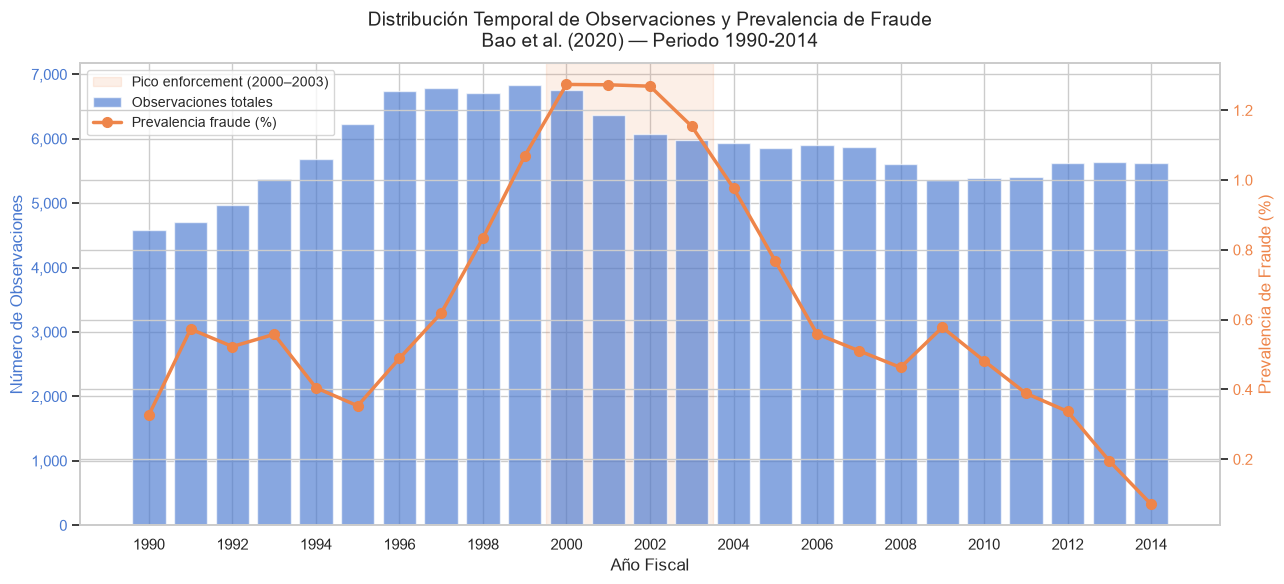

Figura guardada: figures/eda/fig02_temporal_distribution.png

Año con más fraudes absolutos : 2000 (86 fraudes)
Año con mayor prevalencia      : 2000 (1.27%)


In [4]:
# ── Estadísticos temporales ───────────────────────────────────────────────
obs_por_año      = df.groupby('fyear').size()
fraud_por_año    = df.groupby('fyear')['misstate'].sum()
prev_anual       = (fraud_por_año / obs_por_año * 100).round(3)

print("="*55)
print("DISTRIBUCIÓN TEMPORAL")
print("="*55)
print(f"Rango temporal : {int(df['fyear'].min())} – {int(df['fyear'].max())}")
print(f"Años únicos    : {df['fyear'].nunique()}")
print(f"Obs. por año   : {obs_por_año.mean():.0f} (media)  "
      f"{obs_por_año.min()} (mín.)  {obs_por_año.max()} (máx.)")

# Top-5 años con más fraudes
top5 = (pd.DataFrame({
    'Fraudes'       : fraud_por_año,
    'Obs. totales'  : obs_por_año,
    'Prevalencia (%)': prev_anual
}).sort_values('Fraudes', ascending=False).head(5))
print(f"\nTop-5 años con más fraudes:")
print(top5.to_string())

# ── Figura combinada: histograma de obs + línea de prevalencia ────────────
fig, ax1 = plt.subplots(figsize=(13, 6))
años = obs_por_año.index.astype(int)

ax1.bar(años, obs_por_año.values, color='#4878D0', alpha=0.65,
        label='Observaciones totales', zorder=2)
ax1.set_xlabel('Año Fiscal', fontsize=12)
ax1.set_ylabel('Número de Observaciones', fontsize=12, color='#4878D0')
ax1.tick_params(axis='y', labelcolor='#4878D0')
ax1.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, p: f'{int(x):,}'))

ax2 = ax1.twinx()
ax2.plot(años, prev_anual.values, color='#EE854A', marker='o',
         linewidth=2.5, markersize=7, label='Prevalencia fraude (%)', zorder=3)
ax2.set_ylabel('Prevalencia de Fraude (%)', fontsize=12, color='#EE854A')
ax2.tick_params(axis='y', labelcolor='#EE854A')

# Sombreado del pico post-Enron
ax1.axvspan(1999.5, 2003.5, alpha=0.13, color='#EE854A',
            label='Pico enforcement (2000–2003)', zorder=1)

ax1.set_title('Distribución Temporal de Observaciones y Prevalencia de Fraude\n'
              'Bao et al. (2020) — Periodo 1990-2014', fontsize=14, pad=12)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=10)
plt.xticks(años[::2], rotation=45)
plt.tight_layout()
plt.savefig('../figures/eda/fig02_temporal_distribution.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Figura guardada: figures/eda/fig02_temporal_distribution.png")

# Pico
año_max_abs  = int(fraud_por_año.idxmax())
año_max_prev = int(prev_anual.idxmax())
print(f"\nAño con más fraudes absolutos : {año_max_abs} "
      f"({int(fraud_por_año[año_max_abs])} fraudes)")
print(f"Año con mayor prevalencia      : {año_max_prev} "
      f"({prev_anual[año_max_prev]:.2f}%)")


**Interpretación:**
Se aprecia claramente el **pico de enforcement de la SEC en el periodo 2000-2003**, coincidiendo con los escándalos de Enron (2001), WorldCom (2002) y Tyco (2002). La SEC publicó un número inusualmente elevado de AAERs durante estos años para sancionar fraudes que, en muchos casos, habían comenzado en los años 90 pero cuya investigación culminó en ese periodo. Esto tiene una consecuencia metodológica importante: **los fraudes etiquetados en un año dado pueden corresponder a manipulaciones iniciadas varios ejercicios antes**, lo que introduce una complejidad adicional en la interpretación causal de los predictores.

La distribución irregular de fraudes a lo largo del tiempo refuerza la necesidad de un **split temporal estricto** (no aleatorio) para evitar que información del futuro contamine el modelo de entrenamiento.


---
##  Fraude serial 

Un aspecto frecuentemente ignorado en la literatura de detección de fraude contable es el **fraude serial**: una misma empresa (`gvkey`) puede aparecer etiquetada como `misstate=1` durante múltiples ejercicios consecutivos. Esto ocurre porque el fraude contable suele mantenerse durante varios años antes de ser detectado. Su presencia tiene implicaciones directas sobre la validez del split temporal: si una empresa fraudulenta aparece tanto en el conjunto de entrenamiento como en el de test, el modelo puede aprender a identificarla por sus características idiosincráticas (no por el patrón contable general), lo que produciría una sobreestimación del rendimiento real.


ANÁLISIS DE FRAUDE SERIAL
Empresas con ≥1 año de misstate=1 : 402

Distribución de años fraudulentos por empresa:
  1 año  (punto único)  :  172 empresas  ( 42.8%)
  2 años (fraude breve) :   98 empresas  ( 24.4%)
  3+ años (serial)      :  132 empresas  ( 32.8%)

  Máximo  : 13 años de fraude
  Mediana : 2.0 años
  Media   : 2.40 años


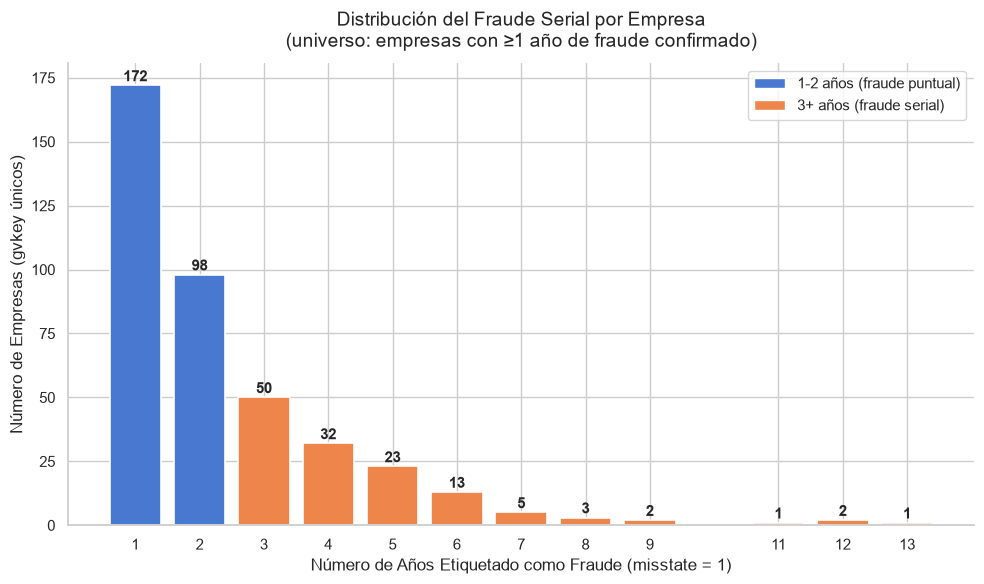

Figura guardada: figures/eda/fig03_serial_fraud.png


In [5]:
# ── Empresas con al menos un año de fraude ────────────────────────────────
df_fraud = df[df['misstate'] == 1]
años_fraude_por_empresa = df_fraud.groupby('gvkey')['misstate'].count()
años_fraude_por_empresa.name = 'años_fraude'

n_empresas_fraud = len(años_fraude_por_empresa)
print("="*60)
print("ANÁLISIS DE FRAUDE SERIAL")
print("="*60)
print(f"Empresas con ≥1 año de misstate=1 : {n_empresas_fraud:,}")

distribucion = años_fraude_por_empresa.value_counts().sort_index()

n_1 = int(distribucion.get(1, 0))
n_2 = int(distribucion.get(2, 0))
n_3plus = int(sum(v for k, v in distribucion.items() if k >= 3))

print(f"\nDistribución de años fraudulentos por empresa:")
print(f"  1 año  (punto único)  : {n_1:>4,} empresas  "
      f"({n_1/n_empresas_fraud*100:5.1f}%)")
print(f"  2 años (fraude breve) : {n_2:>4,} empresas  "
      f"({n_2/n_empresas_fraud*100:5.1f}%)")
print(f"  3+ años (serial)      : {n_3plus:>4,} empresas  "
      f"({n_3plus/n_empresas_fraud*100:5.1f}%)")
print(f"\n  Máximo  : {int(años_fraude_por_empresa.max())} años de fraude")
print(f"  Mediana : {años_fraude_por_empresa.median():.1f} años")
print(f"  Media   : {años_fraude_por_empresa.mean():.2f} años")

# ── Histograma de fraude serial ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
colores_bar = ['#4878D0' if k < 3 else '#EE854A'
               for k in distribucion.index]
bars = ax.bar(distribucion.index, distribucion.values,
              color=colores_bar, edgecolor='white', linewidth=1.2)

for bar, val in zip(bars, distribucion.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.4,
            str(val), ha='center', va='bottom', fontsize=11, fontweight='bold')

from matplotlib.patches import Patch
leyenda = [Patch(facecolor='#4878D0', label='1-2 años (fraude puntual)'),
           Patch(facecolor='#EE854A', label='3+ años (fraude serial)')]
ax.legend(handles=leyenda, fontsize=11)

ax.set_xlabel('Número de Años Etiquetado como Fraude (misstate = 1)', fontsize=12)
ax.set_ylabel('Número de Empresas (gvkey únicos)', fontsize=12)
ax.set_title('Distribución del Fraude Serial por Empresa\n'
             '(universo: empresas con ≥1 año de fraude confirmado)', fontsize=14, pad=12)
ax.set_xticks(distribucion.index)
sns.despine()
plt.tight_layout()
plt.savefig('../figures/eda/fig03_serial_fraud.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figura guardada: figures/eda/fig03_serial_fraud.png")



Una proporción significativa de las empresas fraudulentas del dataset presenta **fraude serial** (etiquetadas como `misstate=1` durante tres o más ejercicios consecutivos). Este fenómeno tiene dos consecuencias metodológicas de primer orden:

1. **Contaminación del split temporal:** si una empresa aparece como fraude en el período de entrenamiento y también en el período de test, el modelo puede memorizar su `gvkey` implícitamente a través de sus características financieras. Para mitigar esto, las observaciones de entrenamiento correspondientes a empresas que *también* son fraudulentas en el test deberán ser **recodificadas a `misstate=0`** (tratamiento de Bao et al., 2020, §3.3).

2. **Justificación del buffer de exclusión:** el año 2002 se excluye del análisis para crear un "período de gracia" entre el entrenamiento y el test, reduciendo la posibilidad de que fraudes que comenzaron antes de 2002 y continuaron después contaminen ambos conjuntos simultáneamente.

Este análisis se completará cuantitativamente en la **Pregunta 7**.


---
##  Valores ausentes

La presencia de valores ausentes (*NaN*) es habitual en datos financieros de Compustat, ya que no todas las empresas reportan todas las partidas contables en todos los años. Antes de cualquier imputación o estrategia de tratamiento, es necesario cuantificar el alcance de los datos ausentes para identificar qué variables podrían requerir tratamiento especial o incluso eliminación.


ANÁLISIS DE VALORES AUSENTES
Columnas con al menos 1 NaN : 14 de 46
Columnas completamente llenas: 32
Columnas con >50% NaN       : 1
Columnas con >30% NaN       : 1

Top-15 columnas con más NaN:
  p_aaer           99.34%  █████████████████████████████████████████████████ ← ALTA
  ch_cm            11.71%  █████
  ch_cs            10.90%  █████
  ch_roa            8.68%  ████
  dpi               6.32%  ███
  ch_fcf            3.70%  █
  ch_rsst           3.32%  █
  dch_wc            3.26%  █
  dch_rec           3.25%  █
  dch_inv           3.16%  █
  soft_assets       0.41%  
  EBIT              0.40%  
  reoa              0.40%  
  bm                0.01%  
  dltt              0.00%  


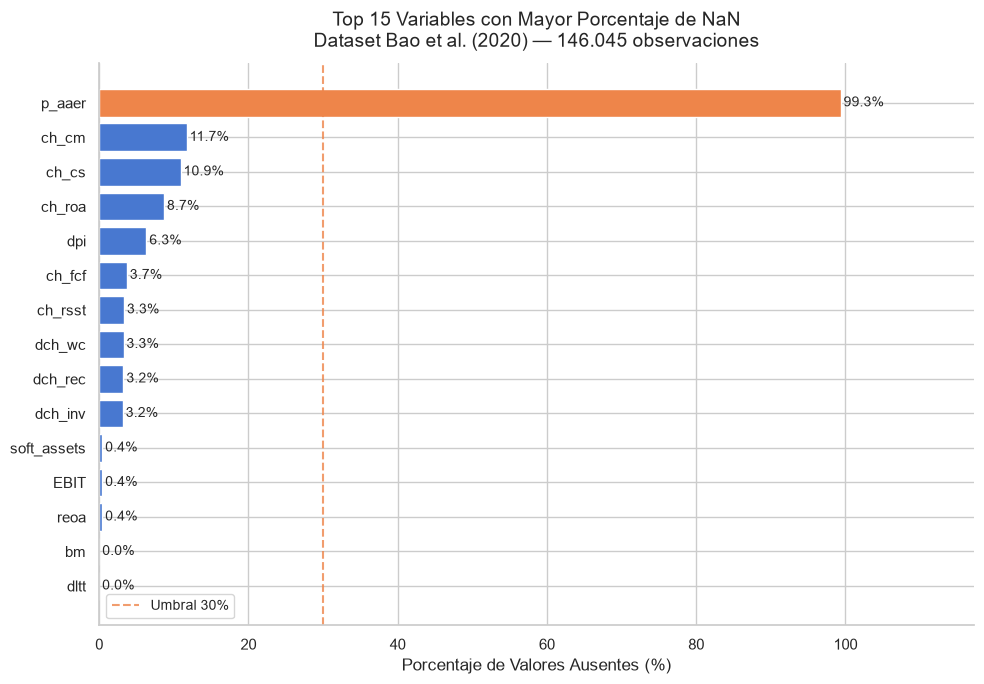

Figura guardada: figures/eda/fig04_missing_values.png

Comparación NaN (%) en clase fraude vs. no fraude (top-5 vars):
  p_aaer           fraude:   0.0%   no fraude: 100.0%
  ch_cm            fraude:   4.7%   no fraude:  11.8%
  ch_cs            fraude:   4.4%   no fraude:  10.9%


  ch_roa           fraude:   4.1%   no fraude:   8.7%
  dpi              fraude:   1.9%   no fraude:   6.3%


In [6]:
# ── Porcentaje de NaN por columna ─────────────────────────────────────────
nan_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
nan_nonzero = nan_pct[nan_pct > 0]

print("="*55)
print("ANÁLISIS DE VALORES AUSENTES")
print("="*55)
print(f"Columnas con al menos 1 NaN : {len(nan_nonzero)} de {df.shape[1]}")
print(f"Columnas completamente llenas: {df.shape[1] - len(nan_nonzero)}")
print(f"Columnas con >50% NaN       : {int((nan_pct > 50).sum())}")
print(f"Columnas con >30% NaN       : {int((nan_pct > 30).sum())}")

print(f"\nTop-15 columnas con más NaN:")
top15 = nan_pct.head(15)
for col, pct in top15.items():
    barra = '█' * int(pct / 2)
    flag  = ' ← ALTA' if pct > 30 else ''
    print(f"  {col:<15s} {pct:6.2f}%  {barra}{flag}")

# ── Figura: barras horizontales top-15 ───────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))
colores_nan = ['#EE854A' if v > 30 else '#4878D0' for v in top15.values]
bars = ax.barh(top15.index[::-1], top15.values[::-1],
               color=colores_nan[::-1], edgecolor='white')

for bar, val in zip(bars, top15.values[::-1]):
    ax.text(bar.get_width() + 0.4,
            bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%', va='center', fontsize=10)

ax.axvline(x=30, color='#EE854A', linestyle='--', alpha=0.8,
           linewidth=1.5, label='Umbral 30%')
ax.set_xlabel('Porcentaje de Valores Ausentes (%)', fontsize=12)
ax.set_title('Top 15 Variables con Mayor Porcentaje de NaN\n'
             'Dataset Bao et al. (2020) — 146.045 observaciones', fontsize=14, pad=12)
ax.set_xlim(0, max(top15.values) * 1.18)
ax.legend(fontsize=10)
sns.despine()
plt.tight_layout()
plt.savefig('../figures/eda/fig04_missing_values.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figura guardada: figures/eda/fig04_missing_values.png")

# ── NaN en la clase de fraude vs. no fraude ───────────────────────────────
print("\nComparación NaN (%) en clase fraude vs. no fraude (top-5 vars):")
top5_nan_cols = nan_pct.head(5).index.tolist()
for col in top5_nan_cols:
    p0 = df[df['misstate']==0][col].isnull().mean() * 100
    p1 = df[df['misstate']==1][col].isnull().mean() * 100
    print(f"  {col:<15s}  fraude: {p1:5.1f}%   no fraude: {p0:5.1f}%")



Las variables con mayor proporción de NaN suelen corresponder a **partidas contables opcionales** que no todas las empresas tienen obligación de reportar: por ejemplo, `ivao` (inversiones largo plazo), `ivst` (inversiones corto plazo), `pstk` (acciones preferentes) o `dltis` (emisiones de deuda largo plazo). Estas variables están disponibles principalmente para empresas de mayor tamaño o aquellas en sectores financieros.

El tratamiento estándar en la literatura (Bao et al., 2020) consiste en **imputar NaN con cero** para las variables contables, lo que equivale a asumir que la ausencia de una partida significa que esa transacción no ocurrió —suposición razonable para partidas opcionales como `ivst` o `pstk`. Esta decisión de imputación se implementará en el notebook de  (preparación de datos).


---
##  Estadísticos descriptivos de las 28 variables crudas

El análisis descriptivo de las variables crudas permite detectar dos problemas comunes en datos financieros: (1) **magnitudes muy heterogéneas** entre variables (activos totales en miles de millones frente a ratios adimensionales), y (2) **distribuciones fuertemente asimétricas** con colas largas hacia valores positivos. Ambos aspectos condicionan el preprocesamiento previo al modelado.


ESTADÍSTICOS DESCRIPTIVOS — 28 VARIABLES CRUDAS COMPUSTAT


           count      mean        std         min     25%      50%      75%         max
act     146045.0   737.848   3744.542      -0.254   8.277   47.501  249.832  152629.000
ap      146045.0   181.993   1047.546       0.000   1.151    6.462   42.259   39903.000
at      146045.0  2374.042  11957.737       0.000  18.281  105.346  672.929  410074.000
ceq     146045.0   887.126   5056.948  -25560.000   6.337   47.308  271.547  284434.000
che     146045.0   218.657   1330.490     -34.000   1.144    9.373   60.286   85709.000
cogs    146045.0  1302.281   7870.666    -366.645   6.795   53.382  372.730  435726.253
csho    146045.0    97.005    540.875       0.000   8.796   22.540   60.736  100092.395
dlc     146045.0   127.228   1023.092      -0.069   0.008    1.363   12.750   75553.000
dltis   146045.0   201.312   1628.477     -19.687   0.000    0.063   24.873  188791.978
dltt    146045.0   538.378   2660.671       0.000   0.000    4.474  126.212  120274.000
dp      146045.0   113.276    66

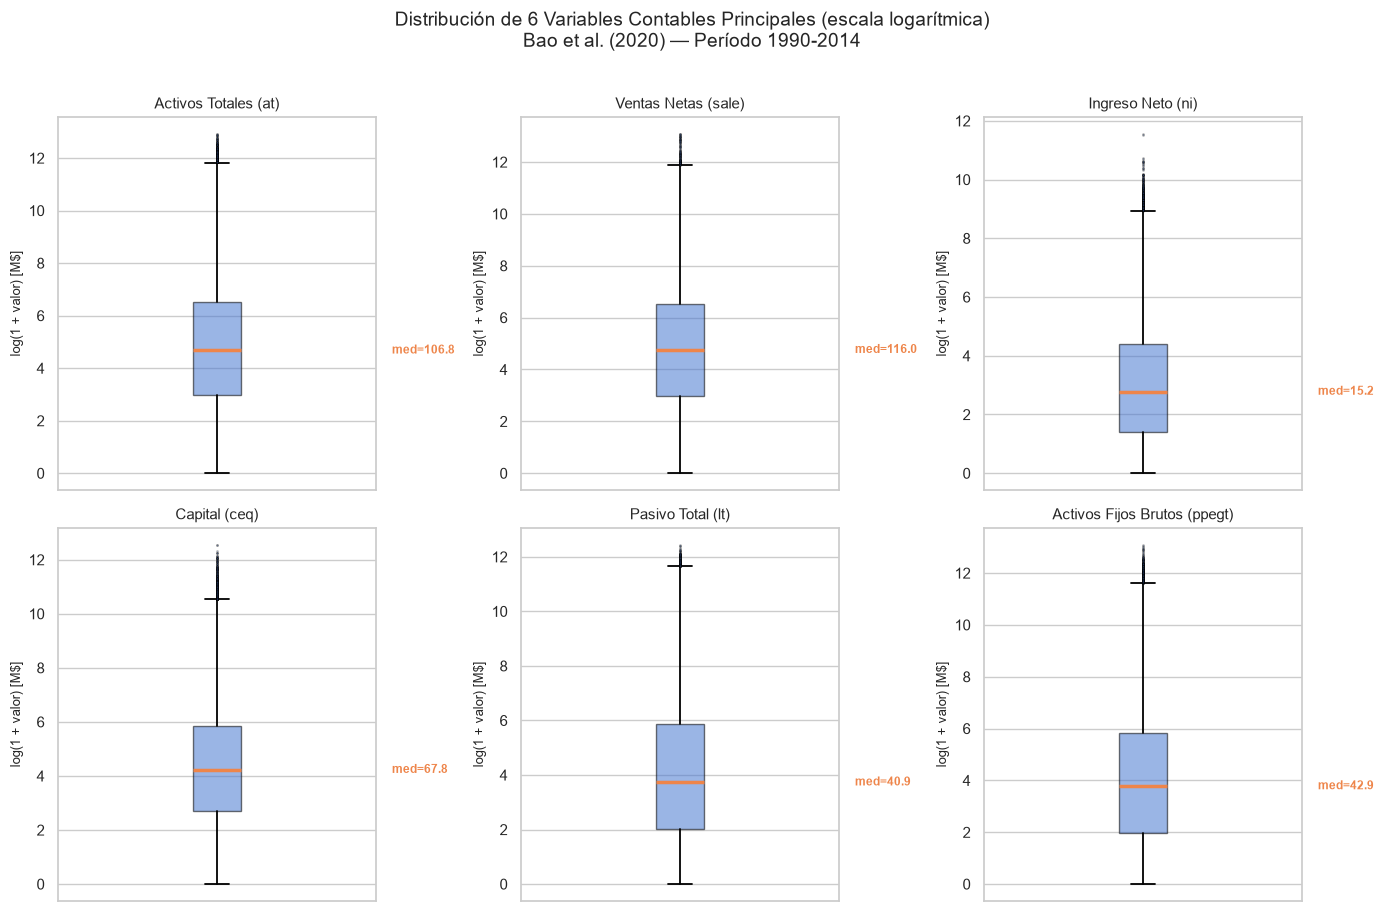

Figura guardada: figures/eda/fig05_raw_boxplots.png


In [7]:
# ── Estadísticos descriptivos de las 28 vars crudas ──────────────────────
print("="*90)
print("ESTADÍSTICOS DESCRIPTIVOS — 28 VARIABLES CRUDAS COMPUSTAT")
print("="*90)
desc = df[cols_raw].describe().T.round(3)
pd.set_option('display.max_columns', 10)
pd.set_option('display.width', 120)
print(desc.to_string())

# Rango de magnitudes
print(f"\nRango de magnitudes (media sobre toda la muestra):")
medias = df[cols_raw].mean().sort_values(ascending=False)
for var, media in medias.head(5).items():
    print(f"  {var:<8s} media = {media:>12,.2f}")
print("  ...")
for var, media in medias.tail(5).items():
    print(f"  {var:<8s} media = {media:>12,.4f}")

# ── Boxplots en escala log de 6 variables principales ────────────────────
vars_box = ['at', 'sale', 'ni', 'ceq', 'lt', 'ppegt']
labels_box = {
    'at'   : 'Activos Totales (at)',
    'sale' : 'Ventas Netas (sale)',
    'ni'   : 'Ingreso Neto (ni)',
    'ceq'  : 'Capital (ceq)',
    'lt'   : 'Pasivo Total (lt)',
    'ppegt': 'Activos Fijos Brutos (ppegt)'
}

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
axes = axes.flatten()

for i, var in enumerate(vars_box):
    datos     = df[var].dropna()
    datos_pos = datos[datos > 0]
    log_datos = np.log1p(datos_pos)

    bp = axes[i].boxplot(
        log_datos,
        patch_artist=True,
        boxprops=dict(facecolor='#4878D0', alpha=0.55),
        medianprops=dict(color='#EE854A', linewidth=2.5),
        flierprops=dict(marker='.', markersize=2, alpha=0.25,
                        markerfacecolor='#4878D0'),
        whiskerprops=dict(linewidth=1.3),
        capprops=dict(linewidth=1.3)
    )
    axes[i].set_title(labels_box[var], fontsize=11, pad=6)
    axes[i].set_ylabel('log(1 + valor) [M$]', fontsize=9)
    axes[i].set_xticks([])
    axes[i].text(1.05, log_datos.median(),
                 f'med={datos_pos.median():.1f}',
                 transform=axes[i].get_yaxis_transform(),
                 va='center', fontsize=8.5, color='#EE854A', fontweight='bold')

fig.suptitle('Distribución de 6 Variables Contables Principales (escala logarítmica)\n'
             'Bao et al. (2020) — Período 1990-2014', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../figures/eda/fig05_raw_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figura guardada: figures/eda/fig05_raw_boxplots.png")


**Interpretación:**
Las variables contables presentan **diferencias de magnitud de varios órdenes**: mientras `at` (activos totales) puede alcanzar decenas de miles de millones de dólares para grandes corporaciones, `prcc_f` (precio de acción al cierre) se mueve en un rango de 0-100 dólares. Esta heterogeneidad hace imprescindible una **estandarización** (centrado y escalado) antes de entrenar modelos sensibles a la escala (regresión logística, SVM, redes neuronales). Los modelos de árboles (Random Forest, XGBoost) son invariantes a escala y no requieren normalización.

Los boxplots en escala logarítmica revelan también la **asimetría positiva pronunciada** de todas las variables: la mediana es notablemente inferior a la media, indicando que el dataset está dominado por pequeñas y medianas empresas, con algunas grandes corporaciones que ejercen palanca en los estadísticos de posición. Esta asimetría motiva el uso de transformaciones como `log(1 + x)` o la estandarización robusta (medianas e IQR).


---
## Validación del split temporal futuro

El diseño experimental de Bao et al. (2020) establece un **split temporal estricto** para evaluar la capacidad predictiva fuera de muestra en un contexto realista (*walk-forward*):

- **Train:** `fyear ≤ 2001` — todos los datos anteriores a la crisis Enron
- **Buffer:** `fyear = 2002` — excluido del análisis para evitar contaminación
- **Test:** `2003 ≤ fyear ≤ 2008` — período de evaluación post-reforma
- **Resto:** `fyear > 2008` — disponible para análisis de robustez

Esta celda cuantifica el tamaño de cada subconjunto y, de forma crítica, identifica el **solapamiento de empresas fraudulentas** entre train y test (fraude serial inter-split).


VALIDACIÓN DEL SPLIT TEMPORAL FUTURO
Subconjunto                             Obs.  Fraudes   Prev.%
----------------------------------------------------------------------
Train   (fyear ≤ 2001)                71,748      514    0.716%
Buffer  (fyear = 2002)                 6,067       77    1.269%
Test    (2003 ≤ fyear ≤ 2008)         35,166      261    0.742%
Fuera de rango (>2008)                33,064      112    0.339%
----------------------------------------------------------------------
TOTAL                                146,045      964    0.660%

PROBLEMA DE FRAUDE SERIAL ENTRE TRAIN Y TEST:
gvkeys fraudulentos en TRAIN :  272
gvkeys fraudulentos en TEST  :  128
gvkeys en AMBOS (serial)     :   40
  → 14.7% de las empresas fraudulentas del train también aparecen como fraude en el test



Observaciones de TRAIN con misstate=1 pertenecientes a empresas
  que también son fraude en TEST (→ candidatas a resetear a 0):
  104 observaciones  (0.145% del train total)
  (20.2% de los fraudes del train)


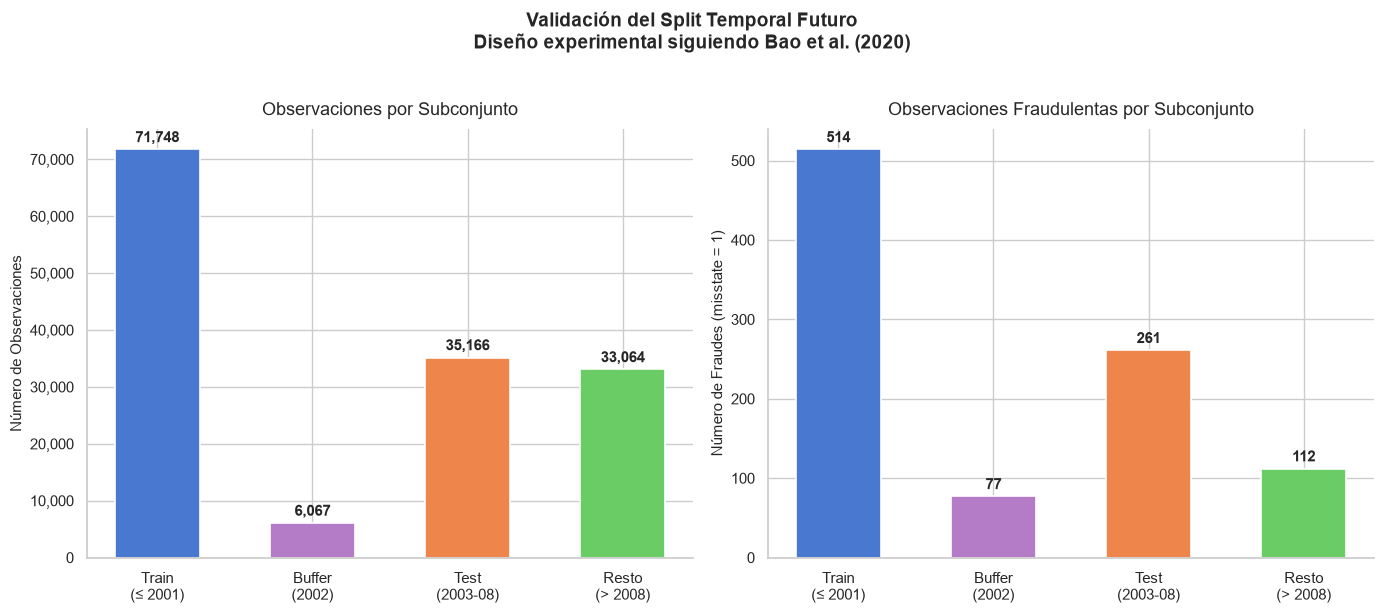

Figura guardada: figures/eda/fig06_temporal_split.png


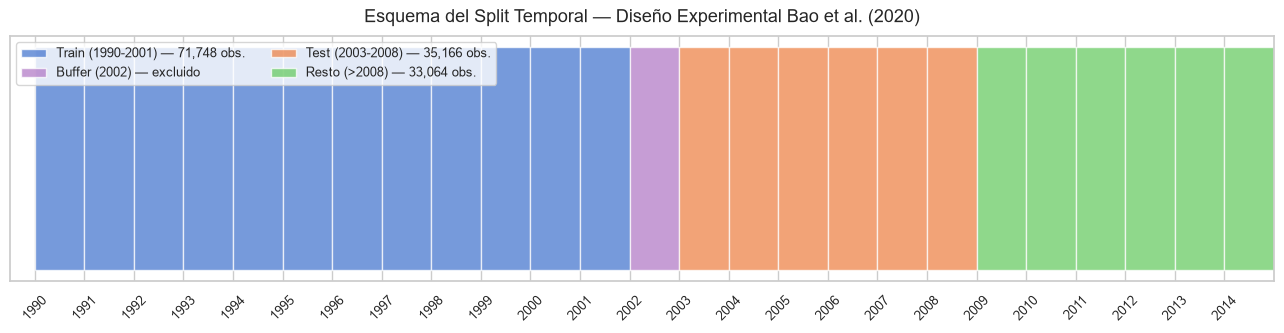

Figura guardada: figures/eda/fig07_split_timeline.png


In [8]:
# ── Máscaras de split ─────────────────────────────────────────────────────
mask_train  = df['fyear'] <= 2001
mask_buffer = df['fyear'] == 2002
mask_test   = df['fyear'].between(2003, 2008)
mask_outro  = ~(mask_train | mask_buffer | mask_test)

subsets = {
    'Train   (fyear ≤ 2001)'       : mask_train,
    'Buffer  (fyear = 2002)'       : mask_buffer,
    'Test    (2003 ≤ fyear ≤ 2008)': mask_test,
    'Fuera de rango (>2008)'       : mask_outro,
}

print("="*70)
print("VALIDACIÓN DEL SPLIT TEMPORAL FUTURO")
print("="*70)
print(f"{'Subconjunto':<35s} {'Obs.':>8} {'Fraudes':>8} {'Prev.%':>8}")
print("-"*70)
resumen_rows = []
for nombre, mask in subsets.items():
    n_obs   = int(mask.sum())
    n_fr    = int(df.loc[mask, 'misstate'].sum())
    prev    = n_fr / n_obs * 100 if n_obs > 0 else 0.0
    print(f"{nombre:<35s} {n_obs:>8,} {n_fr:>8,} {prev:>8.3f}%")
    resumen_rows.append({'Subconjunto': nombre, 'Obs.': n_obs,
                         'Fraudes': n_fr, 'Prevalencia (%)': round(prev, 3)})
print("-"*70)
print(f"{'TOTAL':<35s} {df.shape[0]:>8,} "
      f"{int(df['misstate'].sum()):>8,} "
      f"{df['misstate'].mean()*100:>8.3f}%")

df_resumen = pd.DataFrame(resumen_rows)

# ── Fraude serial inter-split ─────────────────────────────────────────────
gv_fraud_train = set(df.loc[mask_train & (df['misstate']==1), 'gvkey'].unique())
gv_fraud_test  = set(df.loc[mask_test  & (df['misstate']==1), 'gvkey'].unique())
gv_serial      = gv_fraud_train & gv_fraud_test

print(f"\n{'='*70}")
print("PROBLEMA DE FRAUDE SERIAL ENTRE TRAIN Y TEST:")
print("="*70)
print(f"gvkeys fraudulentos en TRAIN : {len(gv_fraud_train):>4}")
print(f"gvkeys fraudulentos en TEST  : {len(gv_fraud_test):>4}")
print(f"gvkeys en AMBOS (serial)     : {len(gv_serial):>4}")
print(f"  → {len(gv_serial)/len(gv_fraud_train)*100:.1f}% de las empresas "
      f"fraudulentas del train también aparecen como fraude en el test")

# Observaciones de train a "limpiar" (resetear misstate→0)
mask_to_clean = mask_train & df['gvkey'].isin(gv_serial) & (df['misstate']==1)
n_clean = int(mask_to_clean.sum())
print(f"\nObservaciones de TRAIN con misstate=1 pertenecientes a empresas")
print(f"  que también son fraude en TEST (→ candidatas a resetear a 0):")
print(f"  {n_clean} observaciones  ({n_clean/int(mask_train.sum())*100:.3f}% del train total)")
print(f"  ({n_clean/int(df.loc[mask_train,'misstate'].sum())*100:.1f}% de los fraudes del train)")

# ── Figura: split overview ────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
colores_split = ['#4878D0', '#B47CC7', '#EE854A', '#6ACC65']
labels_short  = ['Train\n(≤ 2001)', 'Buffer\n(2002)', 'Test\n(2003-08)', 'Resto\n(> 2008)']
obs_vals    = [r['Obs.']    for r in resumen_rows]
fraud_vals  = [r['Fraudes'] for r in resumen_rows]

bars1 = ax1.bar(labels_short, obs_vals, color=colores_split,
                edgecolor='white', linewidth=1.2, width=0.55)
for bar, val in zip(bars1, obs_vals):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + max(obs_vals) * 0.01,
             f'{val:,}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax1.set_title('Observaciones por Subconjunto', fontsize=13, pad=10)
ax1.set_ylabel('Número de Observaciones', fontsize=11)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{int(x):,}'))
sns.despine(ax=ax1)

bars2 = ax2.bar(labels_short, fraud_vals, color=colores_split,
                edgecolor='white', linewidth=1.2, width=0.55)
for bar, val in zip(bars2, fraud_vals):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + max(fraud_vals) * 0.01,
             f'{int(val)}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax2.set_title('Observaciones Fraudulentas por Subconjunto', fontsize=13, pad=10)
ax2.set_ylabel('Número de Fraudes (misstate = 1)', fontsize=11)
sns.despine(ax=ax2)

fig.suptitle('Validación del Split Temporal Futuro\n'
             'Diseño experimental siguiendo Bao et al. (2020)',
             fontsize=14, y=1.02, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/eda/fig06_temporal_split.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figura guardada: figures/eda/fig06_temporal_split.png")

# ── Figura extra: timeline del split ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 3.5))
años_train  = range(1990, 2002)
años_buffer = [2002]
años_test   = range(2003, 2009)
años_resto  = range(2009, 2015)

for a in años_train:
    ax.barh(0, 1, left=a, color='#4878D0', alpha=0.75)
for a in años_buffer:
    ax.barh(0, 1, left=a, color='#B47CC7', alpha=0.75)
for a in años_test:
    ax.barh(0, 1, left=a, color='#EE854A', alpha=0.75)
for a in años_resto:
    ax.barh(0, 1, left=a, color='#6ACC65', alpha=0.75)

ax.set_xlim(1989.5, 2015)
ax.set_yticks([])
ax.set_xticks(range(1990, 2015))
ax.set_xticklabels(range(1990, 2015), rotation=45, fontsize=9)
ax.set_title('Esquema del Split Temporal — Diseño Experimental Bao et al. (2020)',
             fontsize=13, pad=10)
from matplotlib.patches import Patch
ley = [Patch(facecolor='#4878D0', alpha=0.75, label=f'Train (1990-2001) — {obs_vals[0]:,} obs.'),
       Patch(facecolor='#B47CC7', alpha=0.75, label=f'Buffer (2002) — excluido'),
       Patch(facecolor='#EE854A', alpha=0.75, label=f'Test (2003-2008) — {obs_vals[2]:,} obs.'),
       Patch(facecolor='#6ACC65', alpha=0.75, label=f'Resto (>2008) — {obs_vals[3]:,} obs.')]
ax.legend(handles=ley, loc='upper left', fontsize=9, ncol=2)
plt.tight_layout()
plt.savefig('../figures/eda/fig07_split_timeline.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figura guardada: figures/eda/fig07_split_timeline.png")


**Interpretación:**
La validación del split revela el **alcance cuantitativo del problema del fraude serial entre particiones**. Un número no trivial de empresas etiquetadas como fraudulentas en el período de entrenamiento vuelven a aparecer con `misstate=1` en el período de test. Si se dejaran como fraude en el entrenamiento, el modelo aprendería que esas empresas concretas son fraudulentas (en lugar de aprender el patrón contable general), lo que inflaría artificialmente el AUROC en test.

La solución adoptada por Bao et al. (2020), consiste en **resetear a `misstate=0`** todas las observaciones de entrenamiento correspondientes a empresas que aparecerán como fraude en el período de test. Esto reduce el número efectivo de fraudes en train pero garantiza que el modelo no haya "visto" esas empresas etiquetadas durante el entrenamiento.


---
## Hallazgos Clave del EDA



### Tabla resumen

| Dimensión | Valor | Implicación para el modelado |
|-----------|-------|------------------------------|
| **Observaciones totales** | 146.045 | Dataset de tamaño moderado; entrenamiento viable en CPU |
| **Fraudes totales** | 964 | Clase minoritaria extrema |
| **Prevalencia fraude** | 0.6601% | Usar AUROC y NDCG@k, no *accuracy* |
| **Ratio desbalanceo** | 1 : 150 | Evaluar técnicas de resampling solo en el conjunto de train |
| **AAER únicos** | 412 | 412 episodios de enforcement de la SEC |
| **Período cubierto** | 1990–2014 (25 años) | Split temporal viable con período de gracia |
| **Pico de fraudes absolutos** | 2000 (86 fraudes, 1.27%) | Coincide con post-Enron; concentración en 1999-2003 |
| **Empresas con al menos 1 fraude** | 402 gvkeys | Universo reducido de infractores |
| **Fraude puntual (1 año)** | 172 empresas (42.8%) | Casos aislados |
| **Fraude breve (2 años)** | 98 empresas (24.4%) | Fraude confirmado 2 ejercicios |
| **Fraude serial (≥3 años)** | 132 empresas (32.8%) | **Requiere tratamiento especial en el split** |
| **Máximo años de fraude** | 13 años (una empresa) | Fraudes prolongados presentes |
| **Mediana años de fraude** | 2.0 años | La mitad de las empresas fraudulentas ≤ 2 años |
| **gvkeys serial inter-split** | 40 empresas (14.7% del train) | Candidatas a reset en train |
| **Obs. de train a resetear (→ 0)** | 104 observaciones | 20.2% de fraudes de train afectados |
| **Train (≤ 2001)** | 71.748 obs — 514 fraudes (0.716%) | Conjunto de entrenamiento principal |
| **Buffer (2002)** | 6.067 obs — excluido | Período de gracia entre particiones |
| **Test (2003–2008)** | 35.166 obs — 261 fraudes (0.742%) | Conjunto de evaluación primario |
| **Resto (> 2008)** | 33.064 obs | Disponible para análisis de robustez |
| **Variable con más NaN** | `p_aaer`: 99.3% (¡auxiliar, no predictor!) | Esperado: solo se rellena en fraudes |
| **Predictores con >10% NaN** | `ch_cm` (11.7%), `ch_cs` (10.9%) | Variables derivadas; imputar con 0 |
| **Rango de magnitudes** | Varios órdenes (at vs. prcc\_f) | Estandarización obligatoria para LR/SVM |
| **Distribución de variables** | Fuertemente asimétrica (cola derecha) | Considerar log-transform en preprocesado |

### Observaciones 

1. **Métrica principal:** AUROC y NDCG@k (k = 150), en línea con Bao et al. (2020). La *accuracy* es engañosa con un ratio 1:150.

2. **Tratamiento del fraude serial:** Las **40 empresas** cuyos gvkeys aparecen como fraude tanto en el train como en el test requieren ser *reseteadas a `misstate=0`* en el conjunto de entrenamiento (**104 observaciones**). Sin este tratamiento, el modelo podría memorizar patrones idiosincráticos de esas empresas concretas.

3. **Imputación NaN:** Cero para todas las variables contables (las partidas no reportadas equivalen a actividad nula). La variable `p_aaer` se excluirá de los predictores por ser una variable derivada de la etiqueta.


